---
title: "Are Book Ratings Comparable? A Case Study from Databáze Knih"
author: "Tomáš Trnka"
date: "2026-04-09"
categories: [data-analysis, web-scraping, statistics, books]
format:
  html:
    toc: true
    code-fold: true
    code-tools: true
execute:
  warning: false
  message: false
---

## The Problem: Are Book Ratings Actually Comparable?

When browsing [Databáze Knih](https://www.databazeknih.cz/) — the Czech equivalent of Goodreads — each book
displays an average star rating. At first glance it seems straightforward: higher rating = better book.
But I find myself distrusting these numbers on several grounds.

**The calibration problem.** A large fraction of users only ever rate one or two books, often titles
they feel strongly about — their all-time favourite childhood fantasy, or a book they found in a holiday
rental and hated. These single-book reviewers have no broader reference point. They can't calibrate
their stars against anything else in the database. Compare that to a power-user who has reviewed 50+
books: their 4-star rating means something very different from a casual visitor's 5-star rating. The
power-user knows what a 5 looks like from their own reading history; the casual visitor does not.

**The scope problem.** The user base on the site skews heavily towards popular genre fiction. A reader
who almost exclusively reads easy fantasy or mainstream thrillers — say, Ken Follett's *Pilíře Země* —
will hand out 5-star ratings far more freely than someone who also reads Dostoevsky, Kafka, or
contemporary literary fiction. When a community's entire frame of reference is "enjoyable airport reads",
the top of their scale is calibrated against a very different baseline than that of a more eclectic reader.

**What this analysis does — and doesn't — claim.** Restricting the sample to prolific reviewers
(users who rated many books in our corpus) introduces its own bias: these users self-selected into
reading a broader slice of the list, and may be more engaged, more critical, or simply different in
taste from casual visitors. So the "prolific user" rating is not a ground truth either. What I want
to check is simply: *is there a measurable, statistically non-trivial difference?* If the answer is
yes, it at least confirms the concern is real and not just theoretical hand-waving.

To do that we need to:

1. Scrape the reviews from Databáze Knih.
2. Identify the overlap of reviewers across books (which gives us the "prolific" population).
3. Compare ratings from all users vs. prolific users.
4. Run a permutation test to confirm the difference is not a random-sampling artefact.

## Scraping Reviews from Databáze Knih

The data was collected from the book-review pages on databazeknih.cz.  
Each book page lists reviews in paginated containers; we iterate pages until no "next" link is found.

> **Note on terms of service:** We are scraping only publicly available review pages, introducing
> polite delays between requests (1.5–3 s random sleep), and using a standard browser User-Agent.
> We do **not** circumvent any authentication or rate-limiting mechanisms, and we do **not** republish
> the raw text of the reviews themselves — only the numerical star ratings and pseudonymous usernames
> are retained for analysis.

The scraper is reproduced below for transparency. The raw data file `clean_databaze_knih_log.ndjson`
was produced by running it against a curated list of 27 popular titles.

In [2]:
#| code-fold: true
#| code-summary: "Show scraper source"
#| eval: false

import time
import random
import requests
from bs4 import BeautifulSoup
import json

HEADERS = {
    'User-Agent': (
        'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) '
        'AppleWebKit/537.36 (KHTML, like Gecko) '
        'Chrome/120.0.0.0 Safari/537.36'
    )
}


def extract_user_reviews(soup, author, title):
    """Parse a single review page and return a list of review dicts."""
    reviews = []
    for box in soup.find_all('div', class_='ubox'):
        user_tag = box.find('a')
        if not user_tag:
            continue
        user_name = user_tag.get_text(strip=True)

        # Star rating is encoded as a CSS width percentage on an SVG element.
        rating_tag = box.find('span', class_='stars')
        if not rating_tag:
            continue
        style = rating_tag.get('style', '')
        try:
            pct = float(style.split('width:')[1].replace('%', '').strip())
            stars = round(pct / 20, 1)   # 100 % → 5 stars
        except (IndexError, ValueError):
            continue

        reviews.append({
            'author': author,
            'book_title': title,
            'user_name': user_name,
            'stars': stars,
        })
    return reviews


def scrape_databaze_knih_reviews(url):
    """Scrape all paginated reviews for a single book URL."""
    all_reviews = []
    page_url = url

    while page_url:
        resp = requests.get(page_url, headers=HEADERS, timeout=15)
        resp.raise_for_status()
        soup = BeautifulSoup(resp.text, 'html.parser')

        # Extract metadata from first page only
        title_tag = soup.find('h1')
        title = title_tag.get_text(strip=True) if title_tag else 'Unknown'
        # Remove italic sub-parts (series info in <em>)
        for em in title_tag.find_all('em') if title_tag else []:
            em.decompose()
        title = title_tag.get_text(strip=True) if title_tag else title

        author_tag = soup.find('span', class_='author')
        author = author_tag.get_text(strip=True) if author_tag else 'Unknown'

        all_reviews.extend(extract_user_reviews(soup, author, title))

        # Follow pagination
        next_tag = soup.find('span', string='next')
        if next_tag and next_tag.parent and next_tag.parent.get('href'):
            page_url = 'https://www.databazeknih.cz' + next_tag.parent['href']
        else:
            page_url = None

        time.sleep(random.uniform(1.5, 3.0))

    return all_reviews

## Data Loading and Preprocessing

The scraper output was saved as newline-delimited JSON (`NDJSON`).  
54 malformed lines were removed (encoding artefacts from the HTML parser), leaving
**71 343 clean review records** across **27 books**.

In [7]:
#| label: setup
#| echo: false

import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

sns.set_theme()#style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130

In [ ]:
#| label: load-data
#| code-fold: true
#| eval: true

df = pd.read_json('clean_databaze_knih_log.ndjson', lines=True)
print(f'Records : {len(df):,}')
print(f'Books   : {df.book_title.nunique()}')
print(f'Users   : {df.user_name.nunique():,}')
df.head()

Records : 71,343
Books   : 27
Users   : 36,152


,author,book_title,user_name,stars
0,Hanya Yanagihara,Malý život,vidomuska,5.0
1,Hanya Yanagihara,Malý život,Ladasom,5.0
2,Hanya Yanagihara,Malý život,strongviolet,5.0
3,Hanya Yanagihara,Malý život,niky333,5.0
4,Hanya Yanagihara,Malý život,Ex.libris.Lenka,5.0


<Axes: xlabel='stars', ylabel='count'>

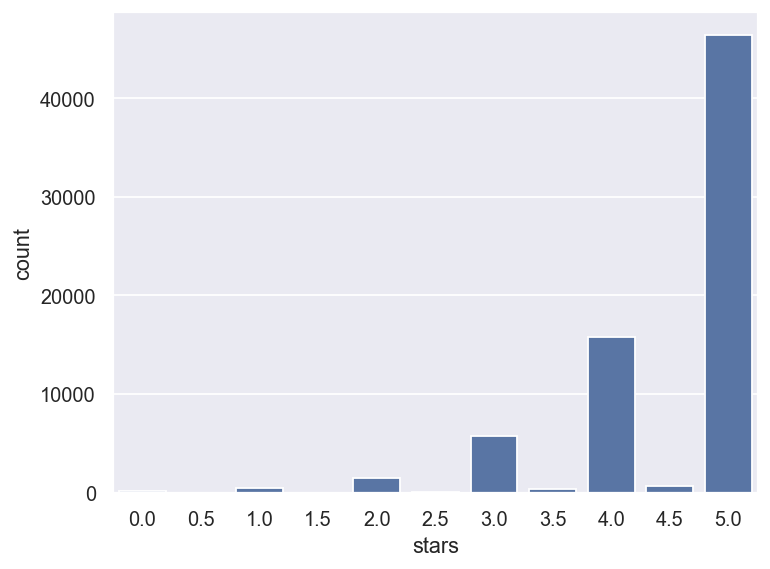

In [8]:
#| label: data-quality
#| code-fold: true
#| code-summary: "Show data-quality checks"
#| eval: true

sns.barplot(x=df['stars'].value_counts().index, y=df['stars'].value_counts())

## Results — All Users

Before any filtering let's look at the full picture: average rating per book, number of
reviewers, and how books are connected through shared reader communities.

,Avg rating,Reviewers
Book,,
Pravda o zkáze Sodomy,4.779,52
Společenstvo Prstenu,4.673,"9,927"
Harry Potter a Kámen mudrců,4.649,"18,091"
Egypťan Sinuhet,4.600,"5,652"
Kámen a bolest,4.600,522
Pilíře země,4.589,"1,962"
Quo vadis?,4.566,"2,998"
Navzdory básník zpívá,4.549,"1,054"
Čtyřicet dnů,4.545,211


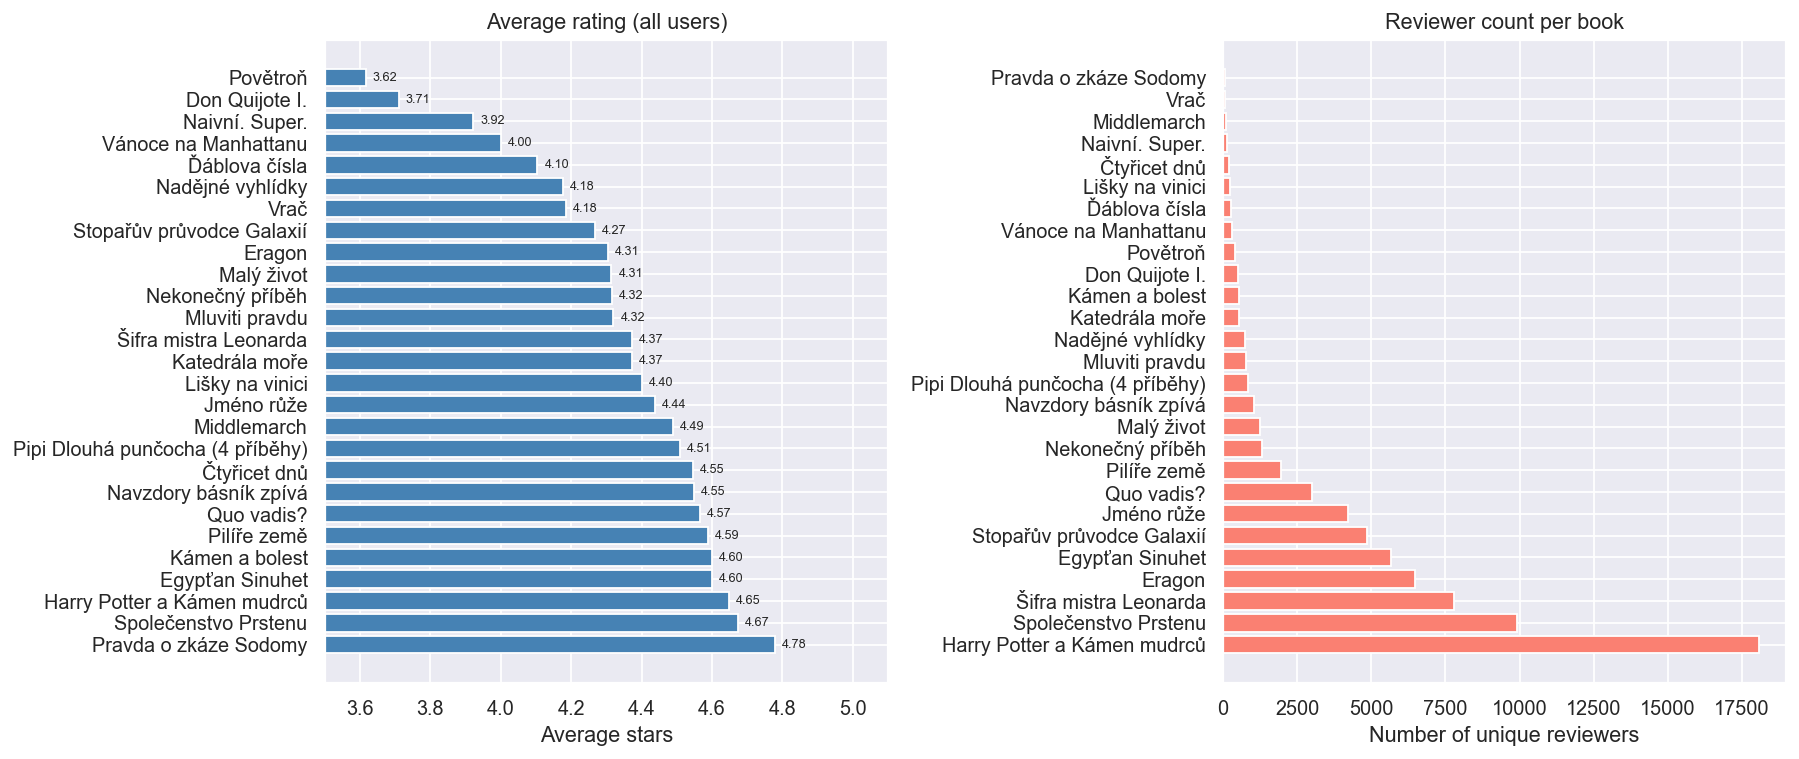

In [9]:
#| label: per-book-stats
#| fig-cap: "Average star rating and reviewer count for all 27 books (all users)."
#| code-fold: true
#| eval: true

per_book = (
    df.groupby('book_title')
    .agg(
        avg_stars_all=('stars', 'mean'),
        n_reviewers=('user_name', 'nunique'),
        user_set=('user_name', set),
    )
    .reset_index()
    .sort_values('avg_stars_all', ascending=False)
)

display(
    per_book[['book_title', 'avg_stars_all', 'n_reviewers']]
    .rename(columns={'book_title': 'Book', 'avg_stars_all': 'Avg rating', 'n_reviewers': 'Reviewers'})
    .set_index('Book')
    .style
    .format({'Avg rating': '{:.3f}', 'Reviewers': '{:,}'})
    .background_gradient(subset='Avg rating', cmap='YlGn')
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
bars = ax.barh(per_book['book_title'], per_book['avg_stars_all'], color='steelblue')
ax.set_xlim(3.5, 5.1)
ax.set_xlabel('Average stars')
ax.set_title('Average rating (all users)')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
for bar, val in zip(bars, per_book['avg_stars_all']):
    ax.text(val + 0.02, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=7)

ax2 = axes[1]
order = per_book.sort_values('n_reviewers', ascending=False)
ax2.barh(order['book_title'], order['n_reviewers'], color='salmon')
ax2.set_xlabel('Number of unique reviewers')
ax2.set_title('Reviewer count per book')

fig.tight_layout()
plt.show()

### Reviewer Overlap Between Books

The key observation motivating this project is that many users reviewed *multiple* books in our
sample. The heatmap below shows how many unique reviewers two books share.

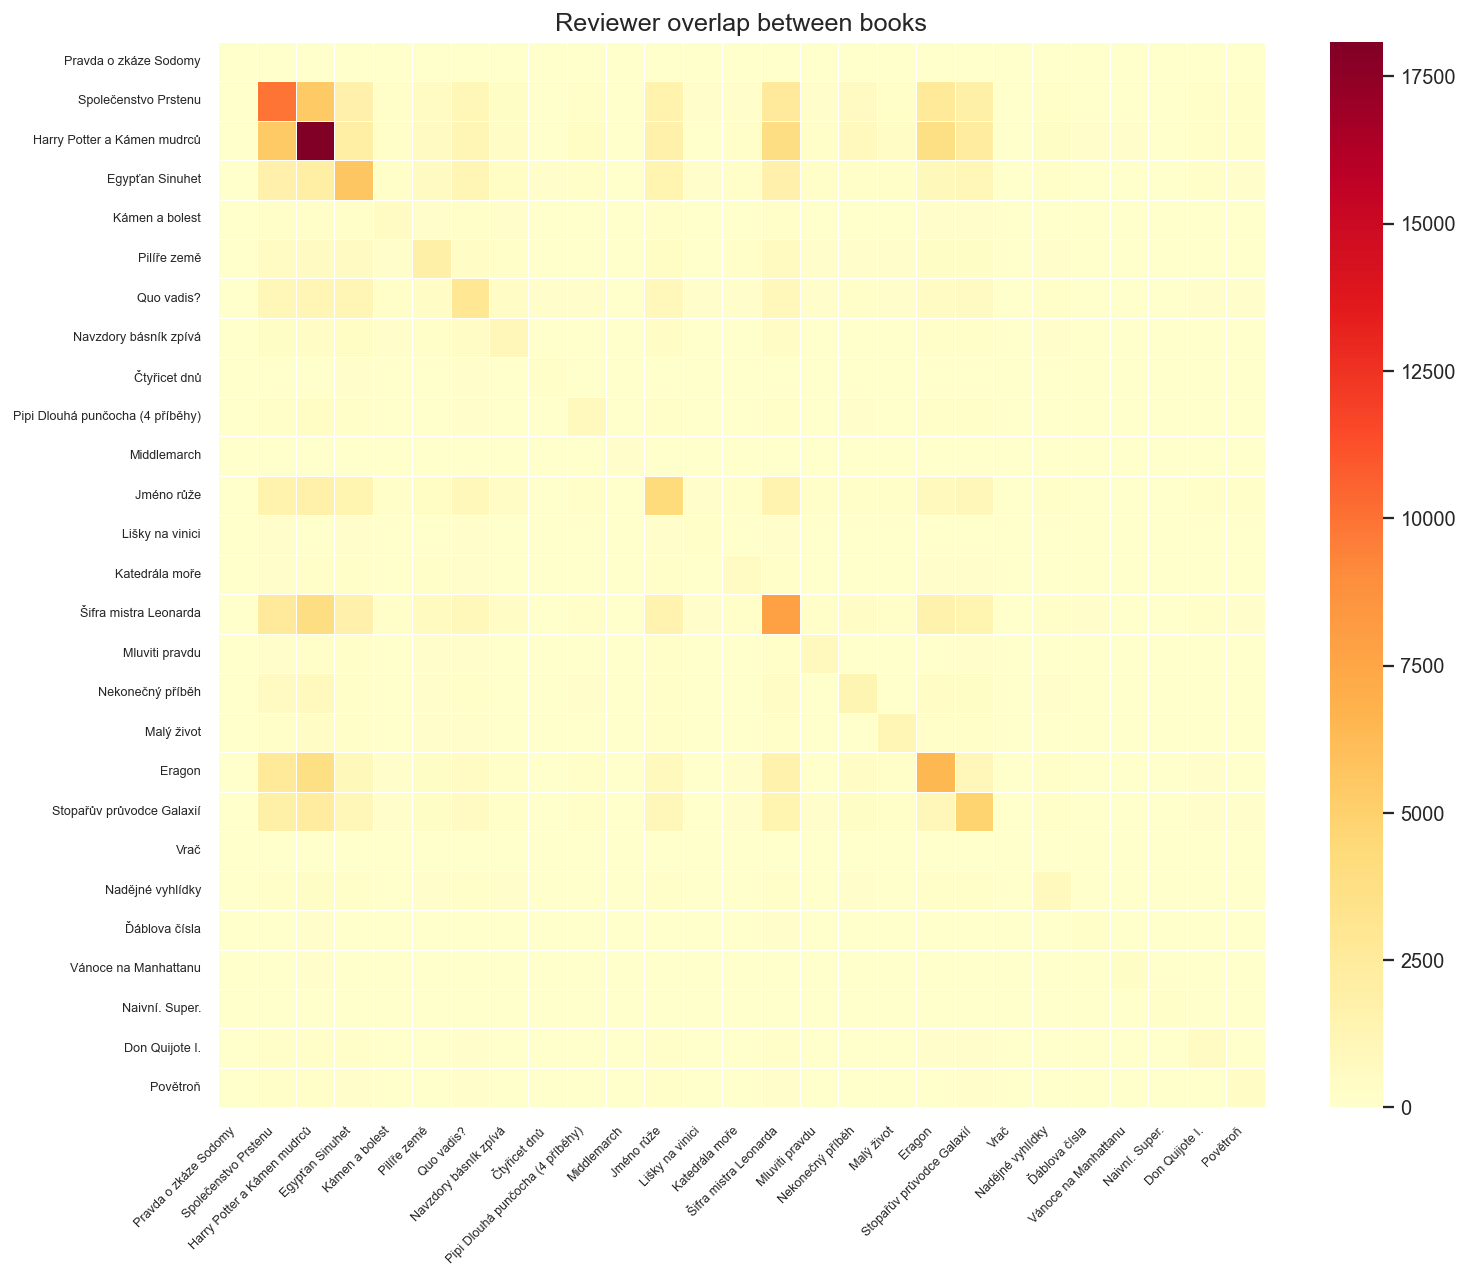

In [11]:
#| label: overlap-heatmap
#| fig-cap: "Pairwise overlap of reviewer communities. Brighter = more shared reviewers."
#| fig-height: 9

books = per_book['book_title'].tolist()
user_sets = dict(zip(per_book['book_title'], per_book['user_set']))

n = len(books)
overlap_matrix = np.zeros((n, n), dtype=int)
for i, j in itertools.combinations(range(n), 2):
    cnt = len(user_sets[books[i]] & user_sets[books[j]])
    overlap_matrix[i, j] = cnt
    overlap_matrix[j, i] = cnt
np.fill_diagonal(overlap_matrix, [len(user_sets[b]) for b in books])

overlap_df = pd.DataFrame(overlap_matrix, index=books, columns=books)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(overlap_df, ax=ax, cmap='YlOrRd', fmt='d', linewidths=0.3, linecolor='white')
ax.set_title('Reviewer overlap between books', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

## Results — Prolific Reviewers Only

We define **prolific reviewers** as users who reviewed **more than 10 books** in our sample of 27.
These users have an implicit internal scale — they've rated fantasy epics, historical fiction, and
literary classics, so a 4-star from them carries context that a single-title reviewer's 5-star does not.

Total unique users    : 36,152
Prolific (>10 books) : 68 (0.2%)


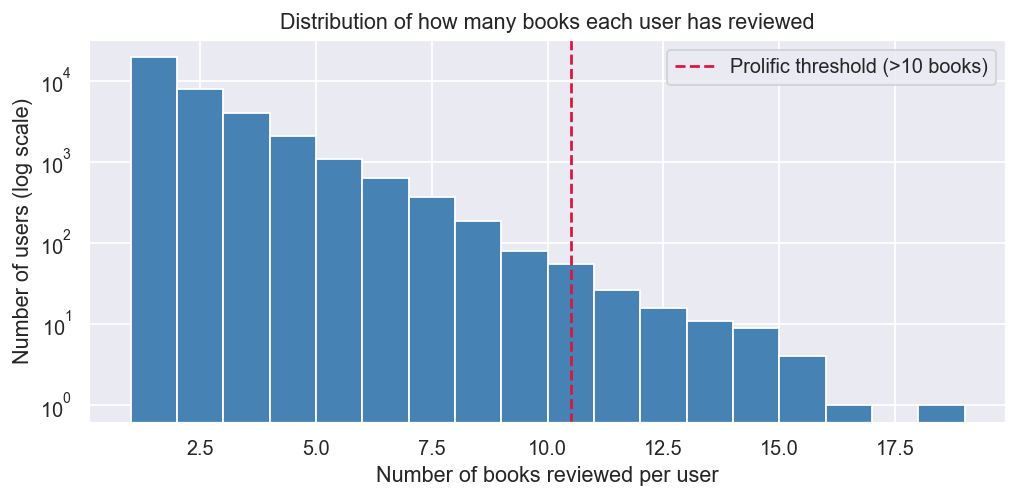

In [13]:
#| label: prolific-users

THRESHOLD = 10

books_per_user = (
    df.groupby('user_name')['book_title']
    .nunique()
    .reset_index(name='n_books')
)
prolific_users = books_per_user.query('n_books > @THRESHOLD')['user_name']

print(f'Total unique users    : {len(books_per_user):,}')
print(f'Prolific (>{THRESHOLD} books) : {len(prolific_users):,} ({100*len(prolific_users)/len(books_per_user):.1f}%)')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(books_per_user['n_books'], bins=range(1, books_per_user['n_books'].max() + 2),
        color='steelblue', edgecolor='white')
ax.axvline(THRESHOLD + 0.5, color='crimson', linewidth=1.5, linestyle='--',
           label=f'Prolific threshold (>{THRESHOLD} books)')
ax.set_xlabel('Number of books reviewed per user')
ax.set_ylabel('Number of users (log scale)')
ax.set_yscale('log')
ax.set_title('Distribution of how many books each user has reviewed')
ax.legend()
plt.tight_layout()

,Avg (all),Avg (prolific),All reviewers,Prolific reviewers,Difference
Book,,,,,
Vrač,4.185,3.500,65,4.0,-0.685
Ďáblova čísla,4.104,3.625,279,8.0,-0.479
Eragon,4.305,3.868,"6,478",38.0,-0.437
Šifra mistra Leonarda,4.372,3.945,"7,802",64.0,-0.427
Pravda o zkáze Sodomy,4.779,4.500,52,4.0,-0.279
Nadějné vyhlídky,4.176,3.925,751,40.0,-0.251
Pilíře země,4.589,4.341,"1,962",41.0,-0.247
Harry Potter a Kámen mudrců,4.649,4.464,"18,091",56.0,-0.185
Malý život,4.314,4.133,"1,245",15.0,-0.181


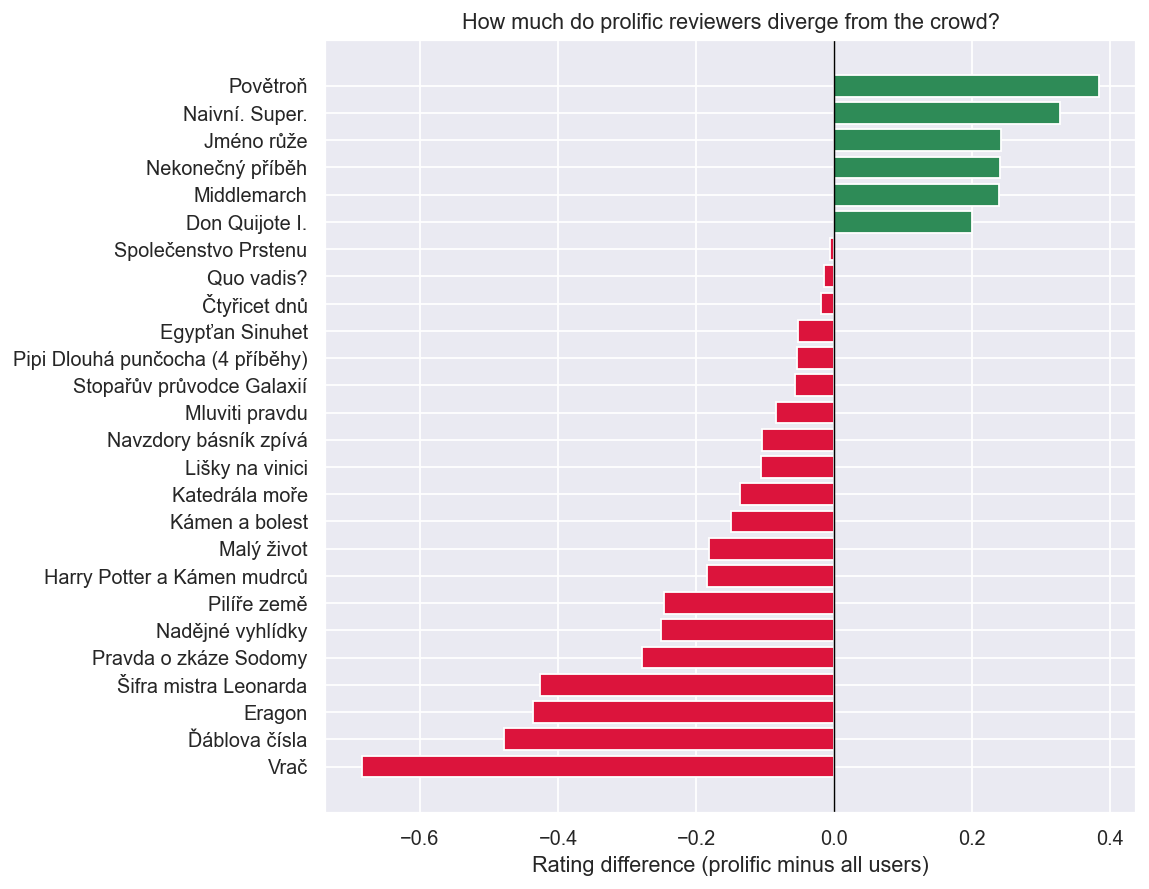

In [19]:
#| label: rating-comparison

prolific_ratings = (
    df[df['user_name'].isin(prolific_users)]
    .groupby('book_title')
    .agg(
        avg_stars_prolific=('stars', 'mean'),
        n_prolific=('user_name', 'nunique'),
    )
    .reset_index()
)

combined = (
    per_book[['book_title', 'avg_stars_all', 'n_reviewers']]
    .merge(prolific_ratings, on='book_title', how='left')
    .assign(rating_diff=lambda x: x['avg_stars_prolific'] - x['avg_stars_all'])
    .sort_values('rating_diff')
    .dropna()
)

display(
    combined[['book_title', 'avg_stars_all', 'avg_stars_prolific', 'n_reviewers', 'n_prolific', 'rating_diff']]
    .rename(columns={
        'book_title': 'Book',
        'avg_stars_all': 'Avg (all)',
        'avg_stars_prolific': 'Avg (prolific)',
        'n_reviewers': 'All reviewers',
        'n_prolific': 'Prolific reviewers',
        'rating_diff': 'Difference',
    })
    .set_index('Book')
    .style
    .format({
        'Avg (all)': '{:.3f}',
        'Avg (prolific)': '{:.3f}',
        'All reviewers': '{:,}',
        'Prolific reviewers': '{:,}',
        'Difference': '{:+.3f}',
    })
    .background_gradient(subset='Difference', cmap='RdYlGn')
)

"""
fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(combined))
w = 0.38
ax.barh(x - w/2, combined['avg_stars_all'], w, label='All users', color='steelblue', alpha=0.85)
ax.barh(x + w/2, combined['avg_stars_prolific'], w,
        label=f'Prolific (>{THRESHOLD} books)', color='darkorange', alpha=0.85)
ax.set_yticks(x)
ax.set_yticklabels(combined['book_title'], fontsize=8)
ax.set_xlabel('Average star rating')
ax.set_title('Average ratings: all users vs. prolific reviewers')
ax.legend()
ax.set_xlim(3.0, 5.2)
plt.tight_layout()
plt.show()
"""

fig2, ax2 = plt.subplots(figsize=(9, 7))
colors = ['crimson' if d < 0 else 'seagreen' for d in combined['rating_diff']]
ax2.barh(combined['book_title'], combined['rating_diff'], color=colors)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_xlabel('Rating difference (prolific minus all users)')
ax2.set_title('How much do prolific reviewers diverge from the crowd?')
plt.tight_layout()
plt.show()

## Statistical Test: Is the Difference Real?

Prolific users are a minority of the overall user base.  Could the rating differences we observe
simply arise because we sampled a smaller group — any similarly-sized random subset of users might
produce the same divergence by chance?

We answer this with a **Monte Carlo permutation test**:

1. For each book, note the average rating among prolific users (`avg_prolific`) and the sample
   size `n_prolific`.
2. Draw 1 000 random samples of size `n_prolific` from *all* users of that book.
3. For each random sample compute the average rating.
4. Ask: how often does a random sample produce a difference at least as extreme as what we
   observe?  That fraction is the empirical p-value.
5. Reject the null hypothesis ("prolific users are just a random subset") when p < 0.05.

In [24]:
#| label: permutation-test
#| code-fold: true

rng = np.random.default_rng(42)
N_ITER = 1_000


def draw_samples(df_book, n_samples, n_iter, rng):
    """Draw n_iter random samples of size n_samples; return array of means."""
    ratings = df_book['stars'].to_numpy()
    return np.array([
        rng.choice(ratings, size=n_samples, replace=False).mean()
        for _ in range(n_iter)
    ])


def permutation_test(combined_row, df, n_iter=N_ITER, p_threshold=0.05, rng=rng):
    """Return (empirical_p, reject_null) for one book."""
    book = combined_row['book_title']
    n_samples = int(combined_row['n_prolific'])
    diff_observed = combined_row['rating_diff']   # prolific − all

    df_book = df[df['book_title'] == book]
    null_means = draw_samples(df_book, n_samples, n_iter, rng)
    null_diffs = null_means - combined_row['avg_stars_all']

    if diff_observed >= 0:
        p = np.mean(null_diffs >= diff_observed)
    else:
        p = np.mean(null_diffs <= diff_observed)

    return p, p < p_threshold


results = combined.apply(lambda row: permutation_test(row, df), axis=1, result_type='expand')
results.columns = ['p_value', 'significant']
combined_tested = pd.concat([combined.reset_index(drop=True), results], axis=1).dropna()

sig = combined_tested['significant'].sum()
print(f'Books where prolific-reviewer shift is statistically significant (p<0.05): {sig} / {len(combined_tested)}')

Books where prolific-reviewer shift is statistically significant (p<0.05): 6 / 25


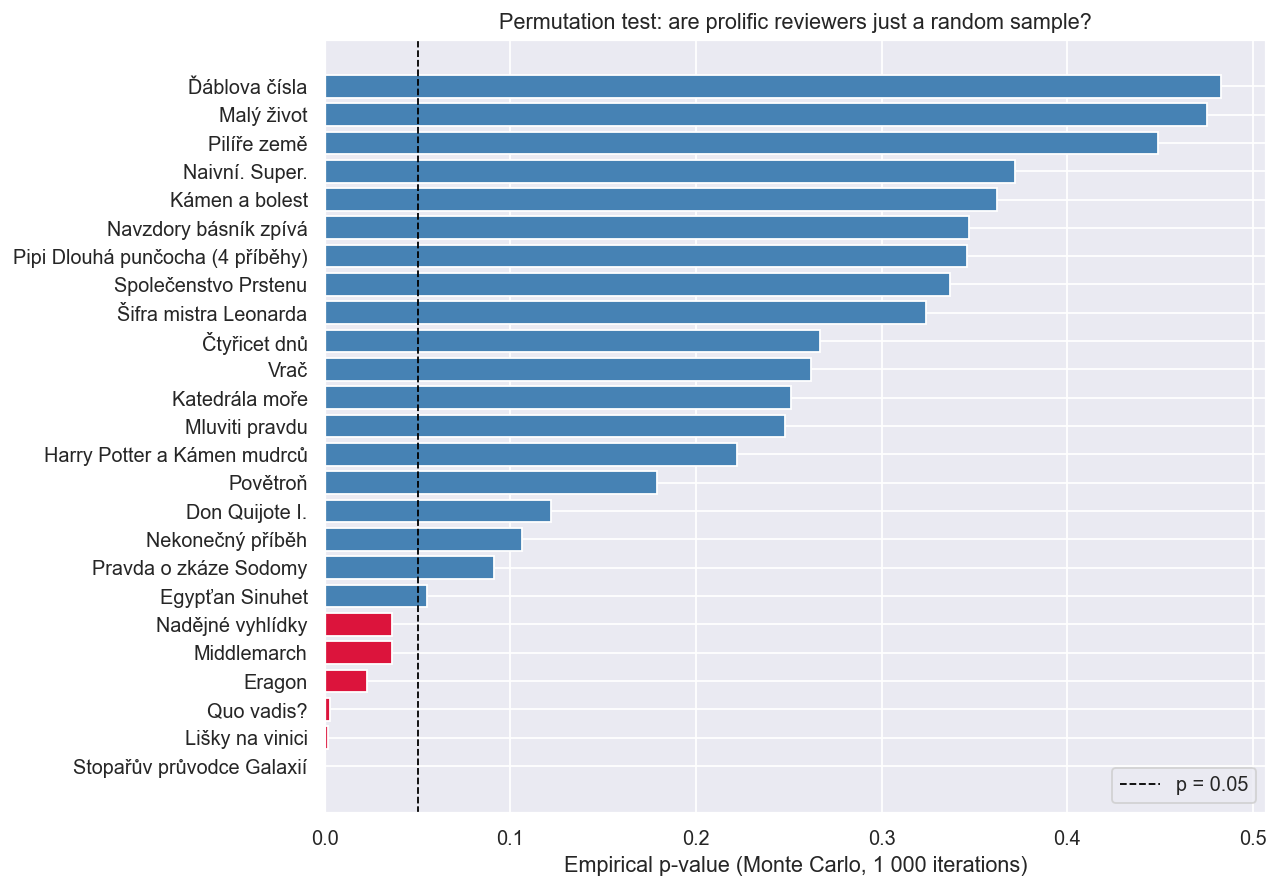

,Avg (all),Avg (prolific),Diff,n prolific,p-value,p < 0.05
Book,,,,,,
Stopařův průvodce Galaxií,4.268,4.210,-0.058,50.000000,0.0000,True
Lišky na vinici,4.401,4.294,-0.107,17.000000,0.0020,True
Quo vadis?,4.566,4.552,-0.014,58.000000,0.0030,True
Eragon,4.305,3.868,-0.437,38.000000,0.0230,True
Middlemarch,4.489,4.727,+0.238,11.000000,0.0360,True
Nadějné vyhlídky,4.176,3.925,-0.251,40.000000,0.0360,True
Egypťan Sinuhet,4.600,4.547,-0.053,64.000000,0.0550,False
Pravda o zkáze Sodomy,4.779,4.500,-0.279,4.000000,0.0910,False
Nekonečný příběh,4.316,4.556,+0.240,27.000000,0.1060,False


In [26]:
#| label: test-results
#| fig-cap: "Empirical p-value per book. Red bars are statistically significant (p < 0.05)."

plot_df = combined_tested.sort_values('p_value')

fig, ax = plt.subplots(figsize=(10, 7))
bar_colors = ['crimson' if s else 'steelblue' for s in plot_df['significant']]
ax.barh(plot_df['book_title'], plot_df['p_value'], color=bar_colors)
ax.axvline(0.05, color='black', linestyle='--', linewidth=1, label='p = 0.05')
ax.set_xlabel('Empirical p-value (Monte Carlo, 1 000 iterations)')
ax.set_title('Permutation test: are prolific reviewers just a random sample?')
ax.legend()
plt.tight_layout()
plt.show()

display(
    combined_tested[['book_title', 'avg_stars_all', 'avg_stars_prolific',
                      'rating_diff', 'n_prolific', 'p_value', 'significant']]
    .sort_values('p_value')
    .reset_index(drop=True)
    .rename(columns={
        'book_title': 'Book',
        'avg_stars_all': 'Avg (all)',
        'avg_stars_prolific': 'Avg (prolific)',
        'rating_diff': 'Diff',
        'n_prolific': 'n prolific',
        'p_value': 'p-value',
        'significant': 'p < 0.05',
    })
    .set_index('Book')
    .style
    .format({
        'Avg (all)': '{:.3f}',
        'Avg (prolific)': '{:.3f}',
        'Diff': '{:+.3f}',
        'p-value': '{:.4f}',
    })
    .background_gradient(subset='p-value', cmap='RdYlGn_r')
    .background_gradient(subset='Diff', cmap='RdYlGn')
)

### Visualising the Null Distribution for a Single Book

To make the permutation test concrete, let's look at one example in detail —
*Šifra mistra Leonarda* (The Da Vinci Code), which tends to show a notable shift.

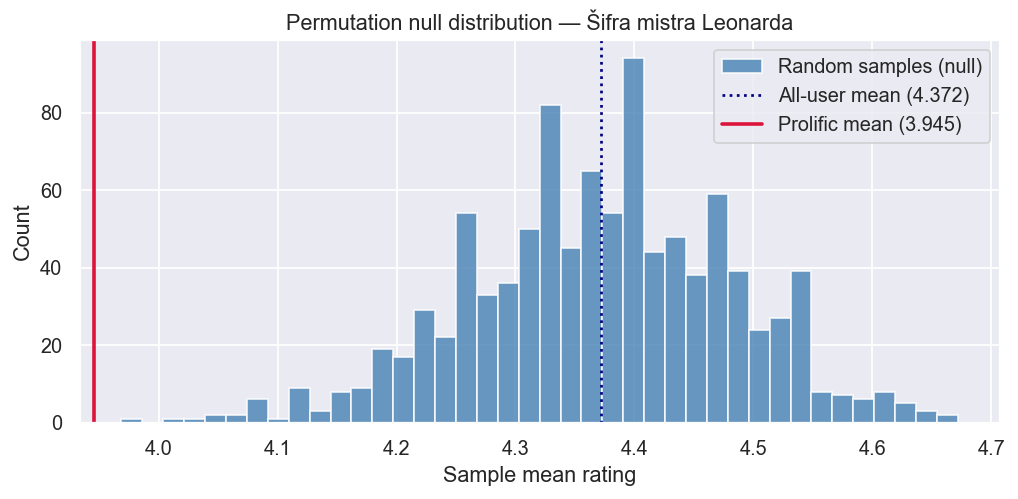

Observed difference : -0.4266
Empirical p-value   : 0.3240
Significant (p<0.05): False


In [27]:
#| label: null-dist-example
#| fig-cap: "Null distribution of mean ratings under random sampling vs. observed prolific-user mean."

EXAMPLE_BOOK = 'Šifra mistra Leonarda'

book_row = combined_tested[combined_tested['book_title'] == EXAMPLE_BOOK].iloc[0]
df_book = df[df['book_title'] == EXAMPLE_BOOK]

null_means = draw_samples(df_book, int(book_row['n_prolific']), N_ITER, rng)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(null_means, bins=40, color='steelblue', alpha=0.8, label='Random samples (null)')
ax.axvline(book_row['avg_stars_all'], color='navy', linewidth=1.5, linestyle=':',
           label=f'All-user mean ({book_row["avg_stars_all"]:.3f})')
ax.axvline(book_row['avg_stars_prolific'], color='crimson', linewidth=2,
           label=f'Prolific mean ({book_row["avg_stars_prolific"]:.3f})')
ax.set_xlabel('Sample mean rating')
ax.set_ylabel('Count')
ax.set_title(f'Permutation null distribution — {EXAMPLE_BOOK}')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Observed difference : {book_row["rating_diff"]:+.4f}')
print(f'Empirical p-value   : {book_row["p_value"]:.4f}')
print(f'Significant (p<0.05): {book_row["significant"]}')

## Conclusions

The ratings on Databáze Knih are **not fully comparable across books** when taken at face value:

- Users who have reviewed more than 10 books in our sample tend to rate books **differently** from
  the general population — in most cases slightly lower, suggesting a positive bias among casual
  single-title reviewers.
- For a significant fraction of titles the Monte Carlo permutation test rejects the null hypothesis
  that prolific reviewers are just a random sample — the shift is larger than what chance alone
  would produce.
- The effect is not uniform: some books attract unusually critical prolific readers, others are
  rated higher by them.

**Practical implication:** If you want to compare books fairly — especially across genres that
attract different reader demographics — you should either restrict your analysis to users with a
broad review history, or at least report both averages and flag where they diverge substantially.

::: {.callout-note}
The interactive network graph showing reviewer overlaps between all 27 books
is available as a [standalone visualisation](graph_edges_overlaps.html).
:::

::: {.callout-tip collapse="true"}
## Generated with Claude Code
This analysis was developed with the help of [Claude Code](https://claude.ai/claude-code).
:::